In [1]:
import PIL
from PIL import Image
import imageio
import numpy as np

In [12]:
filepath = '../assets/ref_images/1.png'
image = Image.open(filepath)
origin_image = image
print(image.size)

(1280, 720)


# Image preprocess

In [13]:
height, width, channels = imageio.imread(filepath).shape
print(height, width, channels)

720 1280 3


/var/folders/qn/m1dv6dd5119b749bt31n43qm0000gn/T/ipykernel_81352/4056124740.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  height, width, channels = imageio.imread(filepath).shape


In [14]:
image = np.array(image)
print(image.shape)

(720, 1280, 3)


In [15]:
height, width = 480, 720
image_height, image_width, _ = image.shape
print(image_height / image_width)

0.5625


crop
Crop by the ratio:


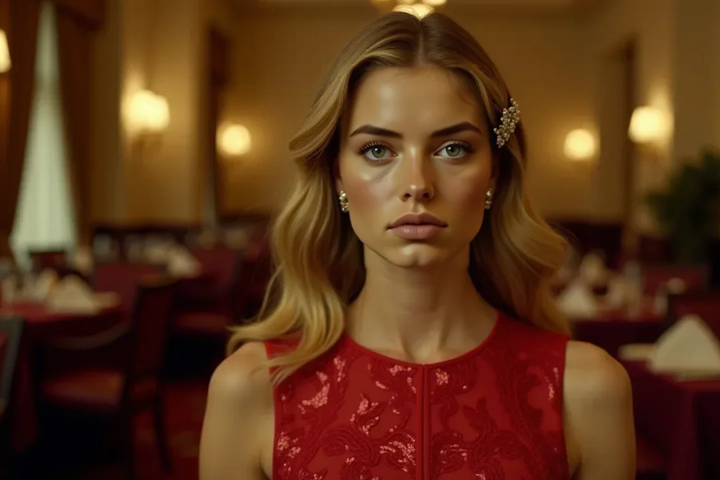

Directly Resize the Image:


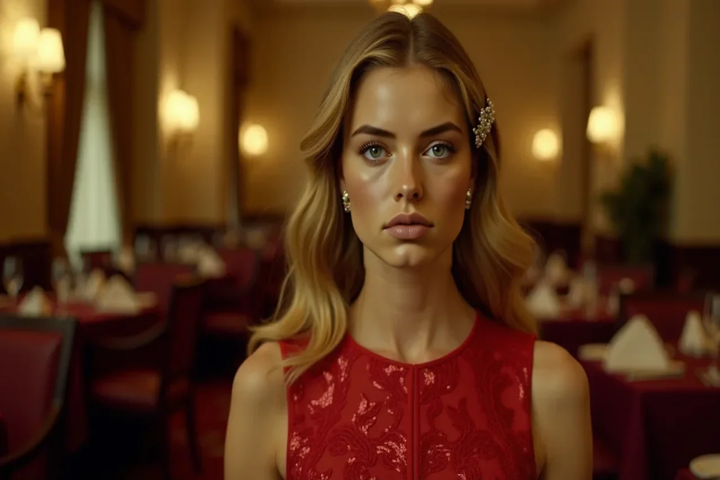

In [16]:
# Fix the height
if image_height / image_width < height / width: # the ratio < 2:3
    print("crop")
    # crop the width
    croped_width = int(image_height / height * width)
    # 计算目标宽度: target_width = image_height / height * width
    left = (image_width - croped_width) // 2 # 左右两边裁剪
    image = image[:, left: left+croped_width]
else:
    print("pad")
    # pad the width
    pad = int((((width / height) * image_height) - image_width) / 2.)
    padded_image = np.zeros((image_height, image_width + pad * 2, 3), dtype=np.uint8)
    padded_image[:, pad:pad+image_width] = image
    image = padded_image

resize_image = Image.fromarray(image).resize((width, height)) # resize
# resize_image.show()
print("Crop by the ratio:")
display(resize_image)

# try only resize
print("Directly Resize the Image:")
origin_image = origin_image.resize((width,height))
# origin_image.show()
display(origin_image)

# Video Preprocess

In [19]:
from insightface.app import FaceAnalysis
from decord import VideoReader

Matplotlib is building the font cache; this may take a moment.


In [ ]:
def parse_video(driving_video_path, max_frame_num):
    """
    处理视频帧数，达到目标帧数；复制第一帧；帧数不足时复制最后一帧，过长则截断
    """
    vr = VideoReader(driving_video_path) # decord.NDarray，类似于numpy
    fps = vr.get_avg_fps() # 获取视频帧率
    video_length = len(vr) # 视频的总帧数

    duration = video_length / fps # 时长:秒
    target_times = np.arange(0, duration, 1/12) # 每秒提取12帧，获取每一帧的时间点
    frame_indices = (target_times * fps).astype(np.int32) # 根据时间点获取帧的ID

    frame_indices = frame_indices[frame_indices < video_length]
    control_frames = vr.get_batch(frame_indices).asnumpy()[:(max_frame_num-1)] # 根据帧索引提取帧,最多max-1个帧
    # 为什么max-1？
    # max-1是为了之后可以复制一次第一帧

    out_frames = len(control_frames) - 1 # 实际帧数
    if  len(control_frames) < max_frame_num - 1: # 帧数不足
        video_lenght_add =  max_frame_num - len(control_frames) - 1
        control_frames = np.concatenate(([control_frames[0]]*2, control_frames[1:len(control_frames)-1], [control_frames[-1]] * video_lenght_add), axis=0) # 帧数不足时，复制最后一帧补全
    else:
        control_frames = np.concatenate(([control_frames[0]]*2, control_frames[1:len(control_frames)-1]), axis=0)

    return control_frames

In [22]:
app = FaceAnalysis(allowed_modules=['detection'])
faces = app.get(resize_image) # 人脸检测，返回2D box
bbox = faces[0]['bbox'] # 这里的0意思是，视频中可能有多个人脸，但是会按照第一个人脸进行crop; 模型本身只能处理单人视频
print(bbox)
# w and h of box

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/user/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/user/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/user/.insightface/models/buffalo_l/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/user/.insightface/models/buffalo_l/w600k_r50.onnx recognition


AssertionError: 